In [1]:
# ============================================================
# NOTEBOOK 06 — CUSTOMER REPEAT-PURCHASE PREDICTION
# ============================================================
# Objective:
# Predict which customers are likely to make another purchase.
#
# This notebook moves from descriptive retention analysis
# toward customer-level predictive targeting.
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")
print("Notebook 06: Customer Repeat-Purchase Prediction")

Libraries imported successfully.
Notebook 06: Customer Repeat-Purchase Prediction


In [2]:
# ============================================================
# CELL 2 — LOAD RAW DATASETS
# ============================================================

from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Raw data directory
RAW_DATA = PROJECT_ROOT / "data" / "raw"

# Load datasets
customers = pd.read_csv(RAW_DATA / "olist_customers_dataset.csv")
orders = pd.read_csv(RAW_DATA / "olist_orders_dataset.csv")
order_items = pd.read_csv(RAW_DATA / "olist_order_items_dataset.csv")
payments = pd.read_csv(RAW_DATA / "olist_order_payments_dataset.csv")
products = pd.read_csv(RAW_DATA / "olist_products_dataset.csv")
category_translation = pd.read_csv(
    RAW_DATA / "product_category_name_translation.csv"
)

print("Datasets loaded successfully.")
print("=" * 60)

print(f"Customers:              {customers.shape}")
print(f"Orders:                 {orders.shape}")
print(f"Order items:            {order_items.shape}")
print(f"Payments:               {payments.shape}")
print(f"Products:               {products.shape}")
print(f"Category translation:   {category_translation.shape}")

Datasets loaded successfully.
Customers:              (99441, 5)
Orders:                 (99441, 8)
Order items:            (112650, 7)
Payments:               (103886, 5)
Products:               (32951, 9)
Category translation:   (71, 2)


In [3]:
# ============================================================
# CELL 3 — CUSTOMER AND ORDER STRUCTURE
# ============================================================

# Convert order timestamp to datetime
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

# Basic counts
unique_customers = customers["customer_unique_id"].nunique()
unique_customer_ids = customers["customer_id"].nunique()
unique_orders = orders["order_id"].nunique()

# Number of orders per customer
orders_per_customer = (
    orders.groupby("customer_id")["order_id"]
    .nunique()
)

print("CUSTOMER / ORDER STRUCTURE")
print("=" * 60)

print(f"Customer records:             {len(customers):,}")
print(f"Unique customer_unique_id:    {unique_customers:,}")
print(f"Unique customer_id:           {unique_customer_ids:,}")
print(f"Unique orders:                {unique_orders:,}")

print("\nOrders per customer_id:")
print(orders_per_customer.describe())

print("\nCustomers with more than one order:")
print(f"{(orders_per_customer > 1).sum():,}")

print("\nCustomers with exactly one order:")
print(f"{(orders_per_customer == 1).sum():,}")

CUSTOMER / ORDER STRUCTURE
Customer records:             99,441
Unique customer_unique_id:    96,096
Unique customer_id:           99,441
Unique orders:                99,441

Orders per customer_id:
count    99441.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: order_id, dtype: float64

Customers with more than one order:
0

Customers with exactly one order:
99,441


In [4]:
# ============================================================
# CELL 4 — IDENTIFY ONE-TIME VS REPEAT CUSTOMERS
# ============================================================

# Map each order to the actual customer identity
customer_orders = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

# Count unique orders per actual customer
customer_order_counts = (
    customer_orders
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index(name="order_count")
)

# Define repeat-purchase target
customer_order_counts["customer_type"] = np.where(
    customer_order_counts["order_count"] > 1,
    "Repeat",
    "One-time"
)

# Summary
customer_type_summary = (
    customer_order_counts["customer_type"]
    .value_counts()
    .rename_axis("customer_type")
    .reset_index(name="customers")
)

customer_type_summary["customer_share_pct"] = (
    customer_type_summary["customers"]
    / len(customer_order_counts)
    * 100
)

print("CUSTOMER REPEAT-PURCHASE DISTRIBUTION")
print("=" * 60)
print(customer_type_summary.to_string(index=False))

print("\nTotal unique customers:", len(customer_order_counts))
print(
    "Repeat customers:",
    (customer_order_counts["customer_type"] == "Repeat").sum()
)
print(
    "One-time customers:",
    (customer_order_counts["customer_type"] == "One-time").sum()
)

CUSTOMER REPEAT-PURCHASE DISTRIBUTION
customer_type  customers  customer_share_pct
     One-time      93099           96.881244
       Repeat       2997            3.118756

Total unique customers: 96096
Repeat customers: 2997
One-time customers: 93099


In [5]:
# ============================================================
# CELL 5 — CREATE CUSTOMER-LEVEL TARGET
# ============================================================

# Convert customer type into binary target
customer_order_counts["repeat_target"] = (
    customer_order_counts["customer_type"]
    .eq("Repeat")
    .astype(int)
)

# Keep only the fields needed for the modeling base
customer_target = customer_order_counts[
    ["customer_unique_id", "order_count", "customer_type", "repeat_target"]
].copy()

print("CUSTOMER-LEVEL TARGET CREATED")
print("=" * 60)

print("Shape:", customer_target.shape)

print("\nTarget distribution:")
print(
    customer_target["repeat_target"]
    .value_counts()
    .sort_index()
)

print("\nTarget distribution (%):")
print(
    customer_target["repeat_target"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nSample:")
display(customer_target.head())

CUSTOMER-LEVEL TARGET CREATED
Shape: (96096, 4)

Target distribution:
repeat_target
0    93099
1     2997
Name: count, dtype: int64

Target distribution (%):
repeat_target
0    96.88
1     3.12
Name: proportion, dtype: float64

Sample:


,customer_unique_id,order_count,customer_type,repeat_target
0,0000366f3b9a7992bf8c76cfdf3221e2,1,One-time,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,One-time,0
2,0000f46a3911fa3c0805444483337064,1,One-time,0
3,0000f6ccb0745a6a4b88665a16c9f078,1,One-time,0
4,0004aac84e0df4da2b147fca70cf8255,1,One-time,0


In [6]:
# ============================================================
# CELL 6 — BUILD FIRST-ORDER CUSTOMER FEATURES
# ============================================================

# ------------------------------------------------------------
# 1. Attach actual customer identity to orders
# ------------------------------------------------------------

orders_customer = orders.merge(
    customers[
        [
            "customer_id",
            "customer_unique_id",
            "customer_state"
        ]
    ],
    on="customer_id",
    how="left"
)

# ------------------------------------------------------------
# 2. Keep valid purchase orders
# ------------------------------------------------------------

orders_customer = orders_customer[
    orders_customer["order_purchase_timestamp"].notna()
].copy()

# ------------------------------------------------------------
# 3. Identify each customer's first order
# ------------------------------------------------------------

orders_customer = orders_customer.sort_values(
    ["customer_unique_id", "order_purchase_timestamp"]
)

first_orders = (
    orders_customer
    .groupby("customer_unique_id", as_index=False)
    .first()
)

# Keep useful first-order fields
first_orders = first_orders[
    [
        "customer_unique_id",
        "order_id",
        "customer_state",
        "order_status",
        "order_purchase_timestamp"
    ]
].copy()

# ------------------------------------------------------------
# 4. Calculate order-level item and revenue features
# ------------------------------------------------------------

order_features = (
    order_items
    .groupby("order_id")
    .agg(
        first_order_items=("order_item_id", "count"),
        first_order_product_count=("product_id", "nunique"),
        first_order_merchandise_value=("price", "sum"),
        first_order_freight_value=("freight_value", "sum")
    )
    .reset_index()
)

order_features["first_order_total_value"] = (
    order_features["first_order_merchandise_value"]
    + order_features["first_order_freight_value"]
)

# ------------------------------------------------------------
# 5. Merge order features onto first orders
# ------------------------------------------------------------

first_orders = first_orders.merge(
    order_features,
    on="order_id",
    how="left"
)

# ------------------------------------------------------------
# 6. Add temporal features
# ------------------------------------------------------------

first_orders["first_order_month"] = (
    first_orders["order_purchase_timestamp"].dt.month
)

first_orders["first_order_day_of_week"] = (
    first_orders["order_purchase_timestamp"].dt.dayofweek
)

first_orders["first_order_hour"] = (
    first_orders["order_purchase_timestamp"].dt.hour
)

# ------------------------------------------------------------
# 7. Merge the prediction target
# ------------------------------------------------------------

customer_features = first_orders.merge(
    customer_target[
        ["customer_unique_id", "repeat_target"]
    ],
    on="customer_unique_id",
    how="inner"
)

print("FIRST-ORDER CUSTOMER FEATURE DATASET")
print("=" * 60)

print("Shape:", customer_features.shape)

print("\nColumns:")
print(customer_features.columns.tolist())

print("\nMissing values:")
print(
    customer_features.isna().sum()
)

print("\nTarget distribution:")
print(
    customer_features["repeat_target"]
    .value_counts()
)

display(customer_features.head())

FIRST-ORDER CUSTOMER FEATURE DATASET
Shape: (96096, 14)

Columns:
['customer_unique_id', 'order_id', 'customer_state', 'order_status', 'order_purchase_timestamp', 'first_order_items', 'first_order_product_count', 'first_order_merchandise_value', 'first_order_freight_value', 'first_order_total_value', 'first_order_month', 'first_order_day_of_week', 'first_order_hour', 'repeat_target']

Missing values:
customer_unique_id                 0
order_id                           0
customer_state                     0
order_status                       0
order_purchase_timestamp           0
first_order_items                707
first_order_product_count        707
first_order_merchandise_value    707
first_order_freight_value        707
first_order_total_value          707
first_order_month                  0
first_order_day_of_week            0
first_order_hour                   0
repeat_target                      0
dtype: int64

Target distribution:
repeat_target
0    93099
1     2997
Name: c

,customer_unique_id,order_id,customer_state,order_status,order_purchase_timestamp,first_order_items,first_order_product_count,first_order_merchandise_value,first_order_freight_value,first_order_total_value,first_order_month,first_order_day_of_week,first_order_hour,repeat_target
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,SP,delivered,2018-05-10 10:56:27,1.0,1.0,129.90,12.00,141.90,5,3,10,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,SP,delivered,2018-05-07 11:11:27,1.0,1.0,18.90,8.29,27.19,5,0,11,0
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,SC,delivered,2017-03-10 21:05:03,1.0,1.0,69.00,17.22,86.22,3,4,21,0
3,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,PA,delivered,2017-10-12 20:29:41,1.0,1.0,25.99,17.63,43.62,10,3,20,0
4,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,SP,delivered,2017-11-14 19:45:42,1.0,1.0,180.00,16.89,196.89,11,1,19,0


In [7]:
# ============================================================
# CELL 7 — INVESTIGATE MISSING FIRST-ORDER PURCHASE DATA
# ============================================================

missing_purchase_features = customer_features[
    customer_features["first_order_total_value"].isna()
].copy()

print("CUSTOMERS WITH MISSING FIRST-ORDER PURCHASE FEATURES")
print("=" * 60)

print("Number of affected customers:", len(missing_purchase_features))

print("\nOrder status distribution:")
print(
    missing_purchase_features["order_status"]
    .value_counts()
)

print("\nOrder status percentages:")
print(
    missing_purchase_features["order_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nRepeat-target distribution:")
print(
    missing_purchase_features["repeat_target"]
    .value_counts()
)

print("\nSample:")
display(
    missing_purchase_features[
        [
            "customer_unique_id",
            "order_id",
            "order_status",
            "order_purchase_timestamp",
            "repeat_target"
        ]
    ].head(10)
)

CUSTOMERS WITH MISSING FIRST-ORDER PURCHASE FEATURES
Number of affected customers: 707

Order status distribution:
order_status
unavailable    582
canceled       117
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

Order status percentages:
order_status
unavailable    82.32
canceled       16.55
created         0.71
invoiced        0.28
shipped         0.14
Name: proportion, dtype: float64

Repeat-target distribution:
repeat_target
0    668
1     39
Name: count, dtype: int64

Sample:


,customer_unique_id,order_id,order_status,order_purchase_timestamp,repeat_target
123,004ad212c650c96c8a48f30855a7bcb8,2c9c2c96702997c879d75f927b76165e,unavailable,2017-09-24 10:45:10,0
177,0071f46a072a9ae25bbe4438b15efe9c,df8c077268f7f3baaac0892eb3143642,unavailable,2017-02-01 00:04:17,0
238,009b0127b727ab0ba422f6d9604487c7,809a282bbd5dbcabb6f2f724fca862ec,canceled,2016-09-13 15:24:19,0
372,00f0b70fdcb8a6e1671b52a2472bd41f,ddaec6fff982b13e7e048b627a11d6da,canceled,2016-10-04 19:41:32,0
475,013b083525868a0437652ebf071cda03,02bfe71c2bbd56f6de9c2c357adff45c,unavailable,2017-12-03 14:28:40,0
774,020d46eecb7bda2b3ab2316a91bb49f6,d6bf93d827293f0b9a1582be0719a1e3,unavailable,2017-09-20 17:48:30,0
922,027b5658f8a94a67c3d037047ca849c5,2ff205d5135b1c7763c6561d2643df51,unavailable,2017-03-23 19:21:05,0
1062,02d73d09e28bcf111eb693e80e33cb51,61a86f238895780d1ddc6344985537ef,unavailable,2017-11-24 23:53:23,0
1098,02ed27f9cd8f0a7ffc59c7e10b46b9c0,85fc293d3e0bf416c547c15d991e096a,unavailable,2017-12-07 20:38:53,0
1246,03459d9b3e14feb0e89b0e5bce4f188d,d5ab426a149bfee66ff88db9c6a8836a,unavailable,2017-02-01 10:40:43,0


In [8]:
# ============================================================
# CELL 8 — FILTER TO COMPLETED FIRST PURCHASES
# ============================================================

# Keep customers whose first order was successfully delivered
model_data = customer_features[
    customer_features["order_status"] == "delivered"
].copy()

print("MODEL POPULATION AFTER FIRST-PURCHASE QUALITY FILTER")
print("=" * 60)

print(f"Original customers:       {len(customer_features):,}")
print(f"Filtered customers:       {len(model_data):,}")
print(f"Excluded customers:       {len(customer_features) - len(model_data):,}")

print("\nOrder status:")
print(model_data["order_status"].value_counts())

print("\nTarget distribution:")
target_summary = (
    model_data["repeat_target"]
    .value_counts()
    .sort_index()
    .rename_axis("repeat_target")
    .reset_index(name="customers")
)

target_summary["share_pct"] = (
    target_summary["customers"]
    / len(model_data)
    * 100
).round(2)

print(target_summary.to_string(index=False))

print("\nMissing feature values:")
print(
    model_data.isna().sum()
)

MODEL POPULATION AFTER FIRST-PURCHASE QUALITY FILTER
Original customers:       96,096
Filtered customers:       93,253
Excluded customers:       2,843

Order status:
order_status
delivered    93253
Name: count, dtype: int64

Target distribution:
 repeat_target  customers  share_pct
             0      90379      96.92
             1       2874       3.08

Missing feature values:
customer_unique_id               0
order_id                         0
customer_state                   0
order_status                     0
order_purchase_timestamp         0
first_order_items                0
first_order_product_count        0
first_order_merchandise_value    0
first_order_freight_value        0
first_order_total_value          0
first_order_month                0
first_order_day_of_week          0
first_order_hour                 0
repeat_target                    0
dtype: int64


In [9]:
# ============================================================
# CELL 9 — FIRST-ORDER VALUE BY CUSTOMER TYPE
# ============================================================

value_comparison = (
    model_data
    .groupby("repeat_target")
    .agg(
        customers=("customer_unique_id", "count"),
        average_first_order_value=("first_order_total_value", "mean"),
        median_first_order_value=("first_order_total_value", "median"),
        average_items=("first_order_items", "mean"),
        median_items=("first_order_items", "median"),
        average_freight=("first_order_freight_value", "mean")
    )
    .reset_index()
)

value_comparison["customer_type"] = value_comparison[
    "repeat_target"
].map({
    0: "One-time",
    1: "Repeat"
})

value_comparison = value_comparison[
    [
        "customer_type",
        "customers",
        "average_first_order_value",
        "median_first_order_value",
        "average_items",
        "median_items",
        "average_freight"
    ]
]

print("FIRST-ORDER BEHAVIOR BY CUSTOMER TYPE")
print("=" * 60)

display(
    value_comparison.round(2)
)

# Calculate percentage difference in average first-order value
one_time_avg = value_comparison.loc[
    value_comparison["customer_type"] == "One-time",
    "average_first_order_value"
].iloc[0]

repeat_avg = value_comparison.loc[
    value_comparison["customer_type"] == "Repeat",
    "average_first_order_value"
].iloc[0]

value_difference_pct = (
    (repeat_avg - one_time_avg)
    / one_time_avg
    * 100
)

print(
    f"\nRepeat vs one-time average first-order value difference: "
    f"{value_difference_pct:.2f}%"
)

FIRST-ORDER BEHAVIOR BY CUSTOMER TYPE


,customer_type,customers,average_first_order_value,median_first_order_value,average_items,median_items,average_freight
0,One-time,90379,160.65,105.40,1.14,1.0,22.77
1,Repeat,2874,146.83,101.14,1.22,1.0,22.78



Repeat vs one-time average first-order value difference: -8.60%


In [10]:
# ============================================================
# CELL 10 — NUMERICAL FEATURE COMPARISON
# ============================================================

numerical_features = [
    "first_order_items",
    "first_order_product_count",
    "first_order_merchandise_value",
    "first_order_freight_value",
    "first_order_total_value"
]

feature_comparison = []

for feature in numerical_features:

    one_time = model_data.loc[
        model_data["repeat_target"] == 0,
        feature
    ]

    repeat = model_data.loc[
        model_data["repeat_target"] == 1,
        feature
    ]

    one_time_mean = one_time.mean()
    repeat_mean = repeat.mean()

    mean_difference_pct = (
        (repeat_mean - one_time_mean)
        / one_time_mean
        * 100
    )

    feature_comparison.append({
        "feature": feature,
        "one_time_mean": one_time_mean,
        "repeat_mean": repeat_mean,
        "difference_pct": mean_difference_pct,
        "one_time_median": one_time.median(),
        "repeat_median": repeat.median()
    })

feature_comparison = pd.DataFrame(feature_comparison)

print("NUMERICAL FEATURE COMPARISON")
print("=" * 70)

display(
    feature_comparison.round(2)
)

NUMERICAL FEATURE COMPARISON


,feature,one_time_mean,repeat_mean,difference_pct,one_time_median,repeat_median
0,first_order_items,1.14,1.22,7.06,1.00,1.00
1,first_order_product_count,1.04,1.07,3.42,1.00,1.00
2,first_order_merchandise_value,137.88,124.05,-10.03,86.99,80.75
3,first_order_freight_value,22.77,22.78,0.06,17.20,16.71
4,first_order_total_value,160.65,146.83,-8.60,105.40,101.14


In [11]:
# ============================================================
# CELL 11 — STATISTICAL SIGNIFICANCE TESTING
# ============================================================

from scipy.stats import mannwhitneyu

statistical_results = []

for feature in numerical_features:

    one_time = model_data.loc[
        model_data["repeat_target"] == 0,
        feature
    ].dropna()

    repeat = model_data.loc[
        model_data["repeat_target"] == 1,
        feature
    ].dropna()

    u_stat, p_value = mannwhitneyu(
        one_time,
        repeat,
        alternative="two-sided"
    )

    statistical_results.append({
        "feature": feature,
        "one_time_median": one_time.median(),
        "repeat_median": repeat.median(),
        "u_statistic": u_stat,
        "p_value": p_value,
        "significant_at_0.05": p_value < 0.05
    })

statistical_results = pd.DataFrame(statistical_results)

print("MANN-WHITNEY U TEST RESULTS")
print("=" * 70)

display(
    statistical_results.round(6)
)

print("\nInterpretation:")
print("H0: The distributions of the feature are the same")
print("H1: The distributions differ between one-time and repeat customers")
print("Significance level: α = 0.05")

MANN-WHITNEY U TEST RESULTS


,feature,one_time_median,repeat_median,u_statistic,p_value,significant_at_0.05
0,first_order_items,1.00,1.00,124411850.0,0.000000,True
1,first_order_product_count,1.00,1.00,126347338.0,0.000000,True
2,first_order_merchandise_value,86.99,80.75,134448300.0,0.001285,True
3,first_order_freight_value,17.20,16.71,132536225.0,0.061012,False
4,first_order_total_value,105.40,101.14,134068529.5,0.003158,True



Interpretation:
H0: The distributions of the feature are the same
H1: The distributions differ between one-time and repeat customers
Significance level: α = 0.05


In [12]:
# ============================================================
# CELL 12 — CATEGORICAL FEATURE ASSOCIATION
# ============================================================

from scipy.stats import chi2_contingency

categorical_features = [
    "customer_state",
    "first_order_month",
    "first_order_day_of_week",
    "first_order_hour"
]

categorical_results = []

for feature in categorical_features:

    contingency_table = pd.crosstab(
        model_data[feature],
        model_data["repeat_target"]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    categorical_results.append({
        "feature": feature,
        "chi2_statistic": chi2,
        "degrees_of_freedom": dof,
        "p_value": p_value,
        "significant_at_0.05": p_value < 0.05
    })

categorical_results = pd.DataFrame(categorical_results)

print("CHI-SQUARE TEST RESULTS")
print("=" * 70)

display(
    categorical_results.round(6)
)

print("\nHypotheses:")
print("H0: Feature and repeat purchase are independent")
print("H1: Feature and repeat purchase are associated")
print("Significance level: α = 0.05")

CHI-SQUARE TEST RESULTS


,feature,chi2_statistic,degrees_of_freedom,p_value,significant_at_0.05
0,customer_state,29.898487,26,0.271838,False
1,first_order_month,96.298856,11,0.000000,True
2,first_order_day_of_week,2.115459,6,0.908779,False
3,first_order_hour,60.941991,23,0.000028,True



Hypotheses:
H0: Feature and repeat purchase are independent
H1: Feature and repeat purchase are associated
Significance level: α = 0.05


In [14]:
%pip install statsmodels

  Using cached statsmodels-0.14.6-cp314-cp314-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp314-cp314-win_amd64.whl (9.6 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   ----


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import statsmodels
print(statsmodels.__version__)

0.14.6


In [16]:
# ============================================================
# CELL 13 — BENJAMINI-HOCHBERG MULTIPLE-TESTING CORRECTION
# ============================================================

from statsmodels.stats.multitest import multipletests

# Combine p-values from numerical and categorical tests
all_p_values = list(statistical_results["p_value"]) + list(
    categorical_results["p_value"]
)

all_features = (
    list(statistical_results["feature"]) +
    list(categorical_results["feature"])
)

# Benjamini-Hochberg FDR correction
reject, adjusted_p_values, _, _ = multipletests(
    all_p_values,
    alpha=0.05,
    method="fdr_bh"
)

multiple_testing_results = pd.DataFrame({
    "feature": all_features,
    "raw_p_value": all_p_values,
    "adjusted_p_value": adjusted_p_values,
    "significant_after_fdr": reject
})

print("MULTIPLE-TESTING CORRECTION")
print("=" * 70)

display(
    multiple_testing_results.round(6)
)

print("\nMethod: Benjamini-Hochberg False Discovery Rate")
print("FDR threshold: α = 0.05")

MULTIPLE-TESTING CORRECTION


,feature,raw_p_value,adjusted_p_value,significant_after_fdr
0,first_order_items,0.000000,0.000000,True
1,first_order_product_count,0.000000,0.000000,True
2,first_order_merchandise_value,0.001285,0.002314,True
3,first_order_freight_value,0.061012,0.078444,False
4,first_order_total_value,0.003158,0.004738,True
5,customer_state,0.271838,0.305818,False
6,first_order_month,0.000000,0.000000,True
7,first_order_day_of_week,0.908779,0.908779,False
8,first_order_hour,0.000028,0.000063,True



Method: Benjamini-Hochberg False Discovery Rate
FDR threshold: α = 0.05


In [17]:
# ============================================================
# CELL 14 — FEATURE PREPARATION AND TRAIN/TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Features available at the time of the first purchase
# ------------------------------------------------------------

feature_columns = [
    "customer_state",
    "first_order_items",
    "first_order_product_count",
    "first_order_merchandise_value",
    "first_order_freight_value",
    "first_order_total_value",
    "first_order_month",
    "first_order_day_of_week",
    "first_order_hour"
]

X = model_data[feature_columns].copy()
y = model_data["repeat_target"].copy()

print("FEATURE MATRIX")
print("=" * 70)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
for feature in feature_columns:
    print("-", feature)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget distribution (%):")
print(
    (y.value_counts(normalize=True) * 100)
    .round(2)
)

# ------------------------------------------------------------
# Stratified train/test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(
    pd.Series(y_train)
    .value_counts()
    .rename_axis("repeat_target")
    .reset_index(name="customers")
)

print("\nTraining target distribution (%):")
print(
    (y_train.value_counts(normalize=True) * 100)
    .round(2)
)

print("\nTesting target distribution:")
print(
    pd.Series(y_test)
    .value_counts()
    .rename_axis("repeat_target")
    .reset_index(name="customers")
)

print("\nTesting target distribution (%):")
print(
    (y_test.value_counts(normalize=True) * 100)
    .round(2)
)

FEATURE MATRIX
X shape: (93253, 9)
y shape: (93253,)

Features:
- customer_state
- first_order_items
- first_order_product_count
- first_order_merchandise_value
- first_order_freight_value
- first_order_total_value
- first_order_month
- first_order_day_of_week
- first_order_hour

Target distribution:
repeat_target
0    90379
1     2874
Name: count, dtype: int64

Target distribution (%):
repeat_target
0    96.92
1     3.08
Name: proportion, dtype: float64

TRAIN / TEST SPLIT
Training samples: 74602
Testing samples: 18651

Training target distribution:
   repeat_target  customers
0              0      72303
1              1       2299

Training target distribution (%):
repeat_target
0    96.92
1     3.08
Name: proportion, dtype: float64

Testing target distribution:
   repeat_target  customers
0              0      18076
1              1        575

Testing target distribution (%):
repeat_target
0    96.92
1     3.08
Name: proportion, dtype: float64


In [18]:
# ============================================================
# CELL 15 — PREPROCESSING + BASELINE LOGISTIC REGRESSION
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------
# Identify feature types
# ------------------------------------------------------------

categorical_features = [
    "customer_state"
]

numerical_features = [
    "first_order_items",
    "first_order_product_count",
    "first_order_merchandise_value",
    "first_order_freight_value",
    "first_order_total_value",
    "first_order_month",
    "first_order_day_of_week",
    "first_order_hour"
]

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

print("\nModel:")
print(logistic_model)

Logistic Regression trained successfully.

Model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['first_order_items',
                                                   'first_order_product_count',
                                                   'first_order_merchandise_value',
                                                   'first_order_freight_value',
                                                   'first_order_total_value',
                                                   'first_order_month',
                                                   'first_order_day_of_week',
                                                   'first_order_hour']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['customer_state'])])),
    

In [19]:
# ============================================================
# CELL 16 — LOGISTIC REGRESSION EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_pred = logistic_model.predict(X_test)

# Probability of repeat purchase
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# Evaluation metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("LOGISTIC REGRESSION — TEST SET EVALUATION")
print("=" * 70)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print("                 Predicted")
print("                 One-time   Repeat")
print(f"Actual One-time  {cm[0,0]:8d} {cm[0,1]:8d}")
print(f"Actual Repeat    {cm[1,0]:8d} {cm[1,1]:8d}")

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["One-time", "Repeat"],
        digits=4,
        zero_division=0
    )
)

LOGISTIC REGRESSION — TEST SET EVALUATION
Accuracy : 0.5496
Precision: 0.0362
Recall   : 0.5304
F1-score : 0.0677
ROC-AUC  : 0.5475
PR-AUC   : 0.0390

CONFUSION MATRIX
                 Predicted
                 One-time   Repeat
Actual One-time      9946     8130
Actual Repeat         270      305

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    One-time     0.9736    0.5502    0.7031     18076
      Repeat     0.0362    0.5304    0.0677       575

    accuracy                         0.5496     18651
   macro avg     0.5049    0.5403    0.3854     18651
weighted avg     0.9447    0.5496    0.6835     18651



In [20]:
# ============================================================
# CELL 17 — RANDOM FOREST MODEL
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------
# Random Forest pipeline
# ------------------------------------------------------------

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_split=10,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# ------------------------------------------------------------
# Train Random Forest
# ------------------------------------------------------------

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")
print("\nModel:")
print(random_forest_model)

Random Forest trained successfully.

Model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['first_order_items',
                                                   'first_order_product_count',
                                                   'first_order_merchandise_value',
                                                   'first_order_freight_value',
                                                   'first_order_total_value',
                                                   'first_order_month',
                                                   'first_order_day_of_week',
                                                   'first_order_hour']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['customer_state'])])),
          

In [21]:
# ============================================================
# CELL 18 — RANDOM FOREST EVALUATION
# ============================================================

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_pred_rf = random_forest_model.predict(X_test)

# Probability of repeat purchase
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# Evaluation metrics
# ------------------------------------------------------------

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

print("RANDOM FOREST — TEST SET EVALUATION")
print("=" * 70)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")
print(f"PR-AUC   : {pr_auc_rf:.4f}")

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print("                 Predicted")
print("                 One-time   Repeat")
print(f"Actual One-time  {cm_rf[0,0]:8d} {cm_rf[0,1]:8d}")
print(f"Actual Repeat    {cm_rf[1,0]:8d} {cm_rf[1,1]:8d}")

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["One-time", "Repeat"],
        digits=4,
        zero_division=0
    )
)

RANDOM FOREST — TEST SET EVALUATION
Accuracy : 0.9321
Precision: 0.0436
Recall   : 0.0574
F1-score : 0.0495
ROC-AUC  : 0.5631
PR-AUC   : 0.0397

CONFUSION MATRIX
                 Predicted
                 One-time   Repeat
Actual One-time     17352      724
Actual Repeat         542       33

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    One-time     0.9697    0.9599    0.9648     18076
      Repeat     0.0436    0.0574    0.0495       575

    accuracy                         0.9321     18651
   macro avg     0.5067    0.5087    0.5072     18651
weighted avg     0.9412    0.9321    0.9366     18651



In [22]:
# ============================================================
# CELL 19 — MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_rf
    ],
    "Precision": [
        precision,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_rf
    ],
    "F1": [
        f1,
        f1_rf
    ],
    "ROC_AUC": [
        roc_auc,
        roc_auc_rf
    ],
    "PR_AUC": [
        pr_auc,
        pr_auc_rf
    ]
})

print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

print(
    model_comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall     F1  ROC_AUC  PR_AUC
Logistic Regression    0.5496     0.0362  0.5304 0.0677   0.5475  0.0390
      Random Forest    0.9321     0.0436  0.0574 0.0495   0.5631  0.0397


In [23]:
# ============================================================
# CELL 20 — RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

# Get the fitted preprocessing pipeline
rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_classifier = random_forest_model.named_steps["classifier"]

# Get transformed feature names
feature_names = rf_preprocessor.get_feature_names_out()

# Get Random Forest feature importances
importances = rf_classifier.feature_importances_

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Clean the feature names for readability
feature_importance["feature"] = (
    feature_importance["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "customer_state_", regex=False)
)

# Sort by importance
feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print("RANDOM FOREST — FEATURE IMPORTANCE")
print("=" * 70)

print(
    feature_importance.head(20).to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print("\nTotal transformed features:", len(feature_importance))

RANDOM FOREST — FEATURE IMPORTANCE
                         feature  importance
       first_order_freight_value    0.198462
         first_order_total_value    0.196049
   first_order_merchandise_value    0.183771
                first_order_hour    0.132379
               first_order_month    0.100477
         first_order_day_of_week    0.085778
               first_order_items    0.014917
customer_state_customer_state_SP    0.010800
customer_state_customer_state_MG    0.008670
customer_state_customer_state_RJ    0.008017
customer_state_customer_state_RS    0.006561
       first_order_product_count    0.006174
customer_state_customer_state_PR    0.006084
customer_state_customer_state_SC    0.005532
customer_state_customer_state_BA    0.004757
customer_state_customer_state_DF    0.004105
customer_state_customer_state_GO    0.003653
customer_state_customer_state_ES    0.003536
customer_state_customer_state_PE    0.003290
customer_state_customer_state_CE    0.002896

Total transformed f

In [24]:
# ============================================================
# CELL 21 — PREPARE DATA FOR ADVANCED BOOSTING MODELS
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Numerical and categorical features
numeric_features = [
    "first_order_items",
    "first_order_product_count",
    "first_order_merchandise_value",
    "first_order_freight_value",
    "first_order_total_value",
    "first_order_month",
    "first_order_day_of_week",
    "first_order_hour"
]

categorical_features = [
    "customer_state"
]

# Preprocessor for tree-based boosting models
boosting_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# Transform training and testing data
X_train_boost = boosting_preprocessor.fit_transform(X_train)
X_test_boost = boosting_preprocessor.transform(X_test)

print("ADVANCED MODEL DATA PREPARATION")
print("=" * 70)

print("Training shape:", X_train_boost.shape)
print("Testing shape :", X_test_boost.shape)
print("Training target:", y_train.shape)
print("Testing target :", y_test.shape)

print("\nRepeat rate:")
print(f"Training: {y_train.mean() * 100:.2f}%")
print(f"Testing : {y_test.mean() * 100:.2f}%")

ADVANCED MODEL DATA PREPARATION
Training shape: (74602, 35)
Testing shape : (18651, 35)
Training target: (74602,)
Testing target : (18651,)

Repeat rate:
Training: 3.08%
Testing : 3.08%


In [26]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 689.0 kB/s eta 0:01:11
   ---------------------------------------- 0.5/48.9 MB 689.0 kB/s eta 0:01:11
    --------------------------------------- 0.8/48.9 MB 701.6 kB/s eta 0:01:09
    --------------------------------------- 1.0/48.9 MB 696.7 kB/s eta 0:01:09
    --------------------------------------- 1.0/48.9 MB 696.7 kB/s eta 0:01:09
   - -------------------------------------- 1.3/48.9 MB 701.1 kB/s eta 0:01:08
   - -------------------------------------- 1.3/48.9 MB 701.1 kB/s eta 0:01:08
   - -------------------------------------- 1.6/48.9 MB 698.3 kB/s eta 0:01:08
   - -------------------------------------- 1.6/48.9 MB 698.3 kB/s eta 0:01:08
   - ----


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.4.1


In [28]:
# ============================================================
# CELL 22B — XGBOOST TRAINING
# ============================================================

from xgboost import XGBClassifier

# Handle the strong class imbalance
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print("Scale positive weight:", round(scale_pos_weight, 2))

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_boost,
    y_train
)

print("\nXGBoost trained successfully.")

Scale positive weight: 31.45

XGBoost trained successfully.


In [29]:
# ============================================================
# CELL 22C — XGBOOST TEST SET EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Predictions
xgb_prob = xgb_model.predict_proba(X_test_boost)[:, 1]

# Default threshold = 0.5
xgb_pred = (xgb_prob >= 0.5).astype(int)

# Metrics
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, zero_division=0)
xgb_recall = recall_score(y_test, xgb_pred, zero_division=0)
xgb_f1 = f1_score(y_test, xgb_pred, zero_division=0)
xgb_roc_auc = roc_auc_score(y_test, xgb_prob)
xgb_pr_auc = average_precision_score(y_test, xgb_prob)

print("XGBOOST — TEST SET EVALUATION")
print("=" * 70)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_pr_auc:.4f}")

# Confusion matrix
cm_xgb = confusion_matrix(y_test, xgb_pred)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print("                 Predicted")
print("                 One-time   Repeat")
print(f"Actual One-time     {cm_xgb[0,0]:5d}     {cm_xgb[0,1]:5d}")
print(f"Actual Repeat       {cm_xgb[1,0]:5d}     {cm_xgb[1,1]:5d}")

# Classification report
print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=["One-time", "Repeat"],
        zero_division=0
    )
)

XGBOOST — TEST SET EVALUATION
Accuracy : 0.6248
Precision: 0.0397
Recall   : 0.4817
F1-score : 0.0734
ROC-AUC  : 0.5643
PR-AUC   : 0.0424

CONFUSION MATRIX
                 Predicted
                 One-time   Repeat
Actual One-time     11376      6700
Actual Repeat         298       277

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    One-time       0.97      0.63      0.76     18076
      Repeat       0.04      0.48      0.07       575

    accuracy                           0.62     18651
   macro avg       0.51      0.56      0.42     18651
weighted avg       0.95      0.62      0.74     18651



In [30]:
%pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 708.7 kB/s eta 0:00:02
   --------------- ------------------------ 0.5/1.4 MB 708.7 kB/s eta 0:00:02
   ----------------------- ---------------- 0.8/1.4 MB 703.9 kB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.4 MB 703.9 kB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 697.9 kB/s eta 0:00:01
   -------------------------------------- - 1.3/1.4 MB 695.7 kB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 695.5 kB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import lightgbm

print("LightGBM version:", lightgbm.__version__)

LightGBM version: 4.7.0


In [32]:
# ============================================================
# CELL 23A — LIGHTGBM TRAINING
# ============================================================

from lightgbm import LGBMClassifier

# Calculate class imbalance
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print("Scale positive weight:", round(scale_pos_weight, 2))

lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_model.fit(
    X_train_boost,
    y_train
)

print("\nLightGBM trained successfully.")

Scale positive weight: 31.45

LightGBM trained successfully.


In [33]:
# ============================================================
# CELL 23B — LIGHTGBM TEST SET EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Probability predictions
lgbm_prob = lgbm_model.predict_proba(X_test_boost)[:, 1]

# Classification using default threshold = 0.5
lgbm_pred = (lgbm_prob >= 0.5).astype(int)

# Metrics
lgbm_accuracy = accuracy_score(y_test, lgbm_pred)
lgbm_precision = precision_score(y_test, lgbm_pred, zero_division=0)
lgbm_recall = recall_score(y_test, lgbm_pred, zero_division=0)
lgbm_f1 = f1_score(y_test, lgbm_pred, zero_division=0)
lgbm_roc_auc = roc_auc_score(y_test, lgbm_prob)
lgbm_pr_auc = average_precision_score(y_test, lgbm_prob)

print("LIGHTGBM — TEST SET EVALUATION")
print("=" * 70)

print(f"Accuracy : {lgbm_accuracy:.4f}")
print(f"Precision: {lgbm_precision:.4f}")
print(f"Recall   : {lgbm_recall:.4f}")
print(f"F1-score : {lgbm_f1:.4f}")
print(f"ROC-AUC  : {lgbm_roc_auc:.4f}")
print(f"PR-AUC   : {lgbm_pr_auc:.4f}")

# Confusion matrix
cm_lgbm = confusion_matrix(y_test, lgbm_pred)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print("                 Predicted")
print("                 One-time   Repeat")
print(f"Actual One-time     {cm_lgbm[0,0]:5d}     {cm_lgbm[0,1]:5d}")
print(f"Actual Repeat       {cm_lgbm[1,0]:5d}     {cm_lgbm[1,1]:5d}")

# Classification report
print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        lgbm_pred,
        target_names=["One-time", "Repeat"],
        zero_division=0
    )
)

LIGHTGBM — TEST SET EVALUATION
Accuracy : 0.6620
Precision: 0.0379
Recall   : 0.4087
F1-score : 0.0694
ROC-AUC  : 0.5571
PR-AUC   : 0.0401

CONFUSION MATRIX
                 Predicted
                 One-time   Repeat
Actual One-time     12112      5964
Actual Repeat         340       235

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    One-time       0.97      0.67      0.79     18076
      Repeat       0.04      0.41      0.07       575

    accuracy                           0.66     18651
   macro avg       0.51      0.54      0.43     18651
weighted avg       0.94      0.66      0.77     18651



In [34]:
%pip install catboost

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached plotly-6.9.0-py3-none-any.whl.metadata (9.0 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 463.1 kB/s eta 0:03:39
   ---------------------------------------- 0.5/101.7 MB 463.1 kB/s eta 0:03:39
   ---------------------------------------- 0.8/101.7 MB 539.7 kB/s eta 0:03:08
   ---------------------------------------- 1.0/101.7 MB 589.5 kB/s eta 0:02:51
   ---------------------------------------- 1.0/101.7 MB 589.5 kB/s eta 0:02:51
    --------------------------------------- 1.3/


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import catboost

print("CatBoost version:", catboost.__version__)

CatBoost version: 1.2.10


In [36]:
# ============================================================
# CELL 24A — CATBOOST TRAINING
# ============================================================

from catboost import CatBoostClassifier

# Calculate class imbalance
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print("Scale positive weight:", round(scale_pos_weight, 2))

catboost_model = CatBoostClassifier(
    iterations=300,
    depth=5,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    scale_pos_weight=scale_pos_weight,
    random_seed=42,
    verbose=False,
    thread_count=-1
)

catboost_model.fit(
    X_train_boost,
    y_train
)

print("\nCatBoost trained successfully.")

Scale positive weight: 31.45

CatBoost trained successfully.


In [37]:
# ============================================================
# CELL 24B — CATBOOST TEST SET EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Probability predictions
catboost_prob = catboost_model.predict_proba(X_test_boost)[:, 1]

# Classification using default threshold = 0.5
catboost_pred = (catboost_prob >= 0.5).astype(int)

# Metrics
catboost_accuracy = accuracy_score(y_test, catboost_pred)
catboost_precision = precision_score(y_test, catboost_pred, zero_division=0)
catboost_recall = recall_score(y_test, catboost_pred, zero_division=0)
catboost_f1 = f1_score(y_test, catboost_pred, zero_division=0)
catboost_roc_auc = roc_auc_score(y_test, catboost_prob)
catboost_pr_auc = average_precision_score(y_test, catboost_prob)

print("CATBOOST — TEST SET EVALUATION")
print("=" * 70)

print(f"Accuracy : {catboost_accuracy:.4f}")
print(f"Precision: {catboost_precision:.4f}")
print(f"Recall   : {catboost_recall:.4f}")
print(f"F1-score : {catboost_f1:.4f}")
print(f"ROC-AUC  : {catboost_roc_auc:.4f}")
print(f"PR-AUC   : {catboost_pr_auc:.4f}")

# Confusion matrix
cm_catboost = confusion_matrix(y_test, catboost_pred)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print("                 Predicted")
print("                 One-time   Repeat")
print(f"Actual One-time     {cm_catboost[0,0]:5d}     {cm_catboost[0,1]:5d}")
print(f"Actual Repeat       {cm_catboost[1,0]:5d}     {cm_catboost[1,1]:5d}")

# Classification report
print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        catboost_pred,
        target_names=["One-time", "Repeat"],
        zero_division=0
    )
)

CATBOOST — TEST SET EVALUATION
Accuracy : 0.6121
Precision: 0.0384
Recall   : 0.4817
F1-score : 0.0711
ROC-AUC  : 0.5770
PR-AUC   : 0.0432

CONFUSION MATRIX
                 Predicted
                 One-time   Repeat
Actual One-time     11139      6937
Actual Repeat         298       277

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    One-time       0.97      0.62      0.75     18076
      Repeat       0.04      0.48      0.07       575

    accuracy                           0.61     18651
   macro avg       0.51      0.55      0.41     18651
weighted avg       0.95      0.61      0.73     18651



In [38]:
# ============================================================
# CELL 25A — ADABOOST TRAINING
# ============================================================

from sklearn.ensemble import AdaBoostClassifier

adaboost_model = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

adaboost_model.fit(
    X_train_boost,
    y_train
)

print("AdaBoost trained successfully.")

AdaBoost trained successfully.


In [39]:
# ============================================================
# CELL 25B — ADABOOST TEST SET EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Probability predictions
adaboost_prob = adaboost_model.predict_proba(X_test_boost)[:, 1]

# Classification using default threshold = 0.5
adaboost_pred = (adaboost_prob >= 0.5).astype(int)

# Metrics
adaboost_accuracy = accuracy_score(y_test, adaboost_pred)
adaboost_precision = precision_score(
    y_test, adaboost_pred, zero_division=0
)
adaboost_recall = recall_score(
    y_test, adaboost_pred, zero_division=0
)
adaboost_f1 = f1_score(
    y_test, adaboost_pred, zero_division=0
)
adaboost_roc_auc = roc_auc_score(
    y_test, adaboost_prob
)
adaboost_pr_auc = average_precision_score(
    y_test, adaboost_prob
)

print("ADABOOST — TEST SET EVALUATION")
print("=" * 70)

print(f"Accuracy : {adaboost_accuracy:.4f}")
print(f"Precision: {adaboost_precision:.4f}")
print(f"Recall   : {adaboost_recall:.4f}")
print(f"F1-score : {adaboost_f1:.4f}")
print(f"ROC-AUC  : {adaboost_roc_auc:.4f}")
print(f"PR-AUC   : {adaboost_pr_auc:.4f}")

# Confusion matrix
cm_adaboost = confusion_matrix(y_test, adaboost_pred)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print("                 Predicted")
print("                 One-time   Repeat")
print(
    f"Actual One-time     {cm_adaboost[0,0]:5d}"
    f"     {cm_adaboost[0,1]:5d}"
)
print(
    f"Actual Repeat       {cm_adaboost[1,0]:5d}"
    f"     {cm_adaboost[1,1]:5d}"
)

# Classification report
print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        adaboost_pred,
        target_names=["One-time", "Repeat"],
        zero_division=0
    )
)

ADABOOST — TEST SET EVALUATION
Accuracy : 0.9692
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000
ROC-AUC  : 0.5282
PR-AUC   : 0.0332

CONFUSION MATRIX
                 Predicted
                 One-time   Repeat
Actual One-time     18076         0
Actual Repeat         575         0

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    One-time       0.97      1.00      0.98     18076
      Repeat       0.00      0.00      0.00       575

    accuracy                           0.97     18651
   macro avg       0.48      0.50      0.49     18651
weighted avg       0.94      0.97      0.95     18651



In [40]:
# ============================================================
# CELL 26 — THRESHOLD OPTIMIZATION
# Compare XGBoost and CatBoost across different thresholds
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# Get predicted probabilities
# ------------------------------------------------------------

xgb_prob = xgb_prob
cat_prob = catboost_prob

# Thresholds to evaluate
thresholds = np.arange(0.05, 0.51, 0.05)

threshold_results = []

for threshold in thresholds:

    # XGBoost predictions
    xgb_pred_threshold = (xgb_prob >= threshold).astype(int)

    threshold_results.append({
        "model": "XGBoost",
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            xgb_pred_threshold,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            xgb_pred_threshold,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            xgb_pred_threshold,
            zero_division=0
        )
    })

    # CatBoost predictions
    cat_pred_threshold = (cat_prob >= threshold).astype(int)

    threshold_results.append({
        "model": "CatBoost",
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            cat_pred_threshold,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            cat_pred_threshold,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            cat_pred_threshold,
            zero_division=0
        )
    })


threshold_df = pd.DataFrame(threshold_results)

print("THRESHOLD OPTIMIZATION RESULTS")
print("=" * 90)

print(
    threshold_df.round(4).to_string(index=False)
)

THRESHOLD OPTIMIZATION RESULTS
   model  threshold  precision  recall     f1
 XGBoost       0.05     0.0309  1.0000 0.0599
CatBoost       0.05     0.0308  1.0000 0.0598
 XGBoost       0.10     0.0310  0.9965 0.0602
CatBoost       0.10     0.0309  1.0000 0.0600
 XGBoost       0.15     0.0311  0.9878 0.0602
CatBoost       0.15     0.0310  0.9930 0.0600
 XGBoost       0.20     0.0312  0.9774 0.0604
CatBoost       0.20     0.0310  0.9878 0.0602
 XGBoost       0.25     0.0312  0.9565 0.0605
CatBoost       0.25     0.0311  0.9791 0.0604
 XGBoost       0.30     0.0314  0.9235 0.0608
CatBoost       0.30     0.0317  0.9670 0.0613
 XGBoost       0.35     0.0315  0.8470 0.0608
CatBoost       0.35     0.0318  0.9165 0.0615
 XGBoost       0.40     0.0337  0.7687 0.0645
CatBoost       0.40     0.0328  0.8348 0.0632
 XGBoost       0.45     0.0364  0.6487 0.0689
CatBoost       0.45     0.0360  0.7096 0.0686
 XGBoost       0.50     0.0397  0.4817 0.0734
CatBoost       0.50     0.0384  0.4817 0.0711


In [41]:
# ============================================================
# CELL 27 — TOP-K CUSTOMER TARGETING / LIFT ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

def top_k_analysis(y_true, probabilities, model_name):

    results = []

    analysis_df = pd.DataFrame({
        "actual": np.asarray(y_true),
        "probability": np.asarray(probabilities)
    })

    # Rank customers from highest predicted probability
    analysis_df = analysis_df.sort_values(
        "probability",
        ascending=False
    ).reset_index(drop=True)

    total_customers = len(analysis_df)
    total_repeat = analysis_df["actual"].sum()
    baseline_rate = total_repeat / total_customers

    print(f"\n{model_name}")
    print("=" * 80)
    print(f"Total customers: {total_customers:,}")
    print(f"Actual repeat customers: {total_repeat:,}")
    print(f"Overall repeat rate: {baseline_rate:.2%}")

    for top_pct in [1, 5, 10, 20, 30, 50]:

        n_customers = int(total_customers * top_pct / 100)

        top_customers = analysis_df.iloc[:n_customers]

        repeat_captured = top_customers["actual"].sum()

        repeat_rate = (
            repeat_captured / n_customers
            if n_customers > 0 else 0
        )

        recall = (
            repeat_captured / total_repeat
            if total_repeat > 0 else 0
        )

        lift = (
            repeat_rate / baseline_rate
            if baseline_rate > 0 else 0
        )

        results.append({
            "model": model_name,
            "top_k_pct": top_pct,
            "customers_targeted": n_customers,
            "repeat_customers_captured": int(repeat_captured),
            "capture_rate_pct": recall * 100,
            "repeat_rate_in_target_pct": repeat_rate * 100,
            "lift": lift
        })

    return pd.DataFrame(results)


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

xgb_topk = top_k_analysis(
    y_test,
    xgb_prob,
    "XGBoost"
)


# ------------------------------------------------------------
# CatBoost
# ------------------------------------------------------------

cat_topk = top_k_analysis(
    y_test,
    cat_prob,
    "CatBoost"
)


# ------------------------------------------------------------
# Combined results
# ------------------------------------------------------------

topk_results = pd.concat(
    [xgb_topk, cat_topk],
    ignore_index=True
)

print("\nTOP-K COMPARISON")
print("=" * 80)

print(
    topk_results.round(3).to_string(index=False)
)


XGBoost
Total customers: 18,651
Actual repeat customers: 575
Overall repeat rate: 3.08%

CatBoost
Total customers: 18,651
Actual repeat customers: 575
Overall repeat rate: 3.08%

TOP-K COMPARISON
   model  top_k_pct  customers_targeted  repeat_customers_captured  capture_rate_pct  repeat_rate_in_target_pct  lift
 XGBoost          1                 186                         11             1.913                      5.914 1.918
 XGBoost          5                 932                         52             9.043                      5.579 1.810
 XGBoost         10                1865                         82            14.261                      4.397 1.426
 XGBoost         20                3730                        151            26.261                      4.048 1.313
 XGBoost         30                5595                        216            37.565                      3.861 1.252
 XGBoost         50                9325                        354            61.565           

In [42]:
# ============================================================
# CELL 28 — SIMPLE BASELINE RANKING COMPARISON
# ============================================================

import numpy as np
import pandas as pd


def baseline_top_k_analysis(y_true, score, method_name, higher_is_more_likely=True):

    df = pd.DataFrame({
        "actual": np.asarray(y_true),
        "score": np.asarray(score)
    })

    # Rank customers according to the baseline score
    df = df.sort_values(
        "score",
        ascending=not higher_is_more_likely
    ).reset_index(drop=True)

    total_customers = len(df)
    total_repeat = df["actual"].sum()
    baseline_rate = total_repeat / total_customers

    results = []

    for top_pct in [1, 5, 10, 20, 30, 50]:

        n = int(total_customers * top_pct / 100)

        top_customers = df.iloc[:n]

        repeat_captured = top_customers["actual"].sum()

        repeat_rate = repeat_captured / n

        capture_rate = repeat_captured / total_repeat

        lift = repeat_rate / baseline_rate

        results.append({
            "method": method_name,
            "top_k_pct": top_pct,
            "customers_targeted": n,
            "repeat_customers_captured": int(repeat_captured),
            "capture_rate_pct": capture_rate * 100,
            "repeat_rate_pct": repeat_rate * 100,
            "lift": lift
        })

    return pd.DataFrame(results)


# ============================================================
# PREPARE TEST-SET FEATURES
# ============================================================

# Use the original test-set feature values.
# X_test contains the raw feature columns before transformation.

baseline_results = []


# ============================================================
# BASELINE 1 — FIRST ORDER TOTAL VALUE
# ============================================================

baseline_results.append(
    baseline_top_k_analysis(
        y_test,
        X_test["first_order_total_value"],
        "First-order total value"
    )
)


# ============================================================
# BASELINE 2 — FIRST ORDER MERCHANDISE VALUE
# ============================================================

baseline_results.append(
    baseline_top_k_analysis(
        y_test,
        X_test["first_order_merchandise_value"],
        "First-order merchandise value"
    )
)


# ============================================================
# BASELINE 3 — FIRST ORDER ITEMS
# ============================================================

baseline_results.append(
    baseline_top_k_analysis(
        y_test,
        X_test["first_order_items"],
        "First-order items"
    )
)


# ============================================================
# ML MODELS
# ============================================================

# XGBoost
baseline_results.append(
    baseline_top_k_analysis(
        y_test,
        xgb_prob,
        "XGBoost"
    )
)


# CatBoost
baseline_results.append(
    baseline_top_k_analysis(
        y_test,
        cat_prob,
        "CatBoost"
    )
)


# ============================================================
# COMBINE RESULTS
# ============================================================

baseline_comparison = pd.concat(
    baseline_results,
    ignore_index=True
)


print("BASELINE vs ML TOP-K COMPARISON")
print("=" * 100)

print(
    baseline_comparison.round(3).to_string(index=False)
)

BASELINE vs ML TOP-K COMPARISON
                       method  top_k_pct  customers_targeted  repeat_customers_captured  capture_rate_pct  repeat_rate_pct  lift
      First-order total value          1                 186                          1             0.174            0.538 0.174
      First-order total value          5                 932                         28             4.870            3.004 0.974
      First-order total value         10                1865                         51             8.870            2.735 0.887
      First-order total value         20                3730                        113            19.652            3.029 0.983
      First-order total value         30                5595                        169            29.391            3.021 0.980
      First-order total value         50                9325                        279            48.522            2.992 0.970
First-order merchandise value          1                 186     

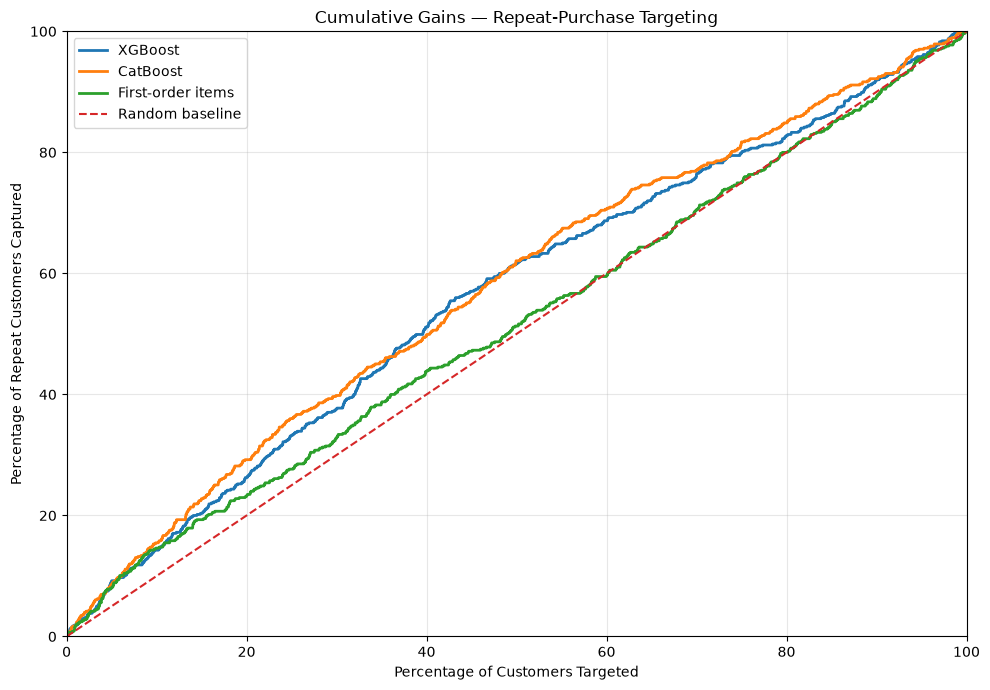

In [43]:
# ============================================================
# CELL 29 — CUMULATIVE GAINS / LIFT CURVE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def cumulative_gains(y_true, scores):

    df = pd.DataFrame({
        "actual": np.asarray(y_true),
        "score": np.asarray(scores)
    })

    # Rank customers by predicted probability
    df = df.sort_values(
        "score",
        ascending=False
    ).reset_index(drop=True)

    df["cumulative_repeat"] = df["actual"].cumsum()

    total_repeat = df["actual"].sum()
    total_customers = len(df)

    df["population_pct"] = (
        np.arange(1, total_customers + 1)
        / total_customers
        * 100
    )

    df["cumulative_capture_pct"] = (
        df["cumulative_repeat"]
        / total_repeat
        * 100
    )

    return df


# ============================================================
# CALCULATE CURVES
# ============================================================

xgb_gains = cumulative_gains(
    y_test,
    xgb_prob
)

cat_gains = cumulative_gains(
    y_test,
    cat_prob
)

items_gains = cumulative_gains(
    y_test,
    X_test["first_order_items"]
)


# ============================================================
# PLOT CUMULATIVE GAINS
# ============================================================

plt.figure(figsize=(10, 7))

plt.plot(
    xgb_gains["population_pct"],
    xgb_gains["cumulative_capture_pct"],
    label="XGBoost",
    linewidth=2
)

plt.plot(
    cat_gains["population_pct"],
    cat_gains["cumulative_capture_pct"],
    label="CatBoost",
    linewidth=2
)

plt.plot(
    items_gains["population_pct"],
    items_gains["cumulative_capture_pct"],
    label="First-order items",
    linewidth=2
)

# Random targeting baseline
plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    label="Random baseline"
)

plt.xlabel("Percentage of Customers Targeted")
plt.ylabel("Percentage of Repeat Customers Captured")

plt.title(
    "Cumulative Gains — Repeat-Purchase Targeting"
)

plt.legend()
plt.grid(alpha=0.3)

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# CELL 30 — FINAL MODEL SELECTION SUMMARY
# ============================================================

final_model_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "AdaBoost"
    ],
    "Accuracy": [
        0.5496,
        0.9321,
        0.6248,
        0.6620,
        0.6121,
        0.9692
    ],
    "Precision": [
        0.0362,
        0.0436,
        0.0397,
        0.0379,
        0.0384,
        0.0000
    ],
    "Recall": [
        0.5304,
        0.0574,
        0.4817,
        0.4087,
        0.4817,
        0.0000
    ],
    "F1": [
        0.0677,
        0.0495,
        0.0734,
        0.0694,
        0.0711,
        0.0000
    ],
    "ROC_AUC": [
        0.5475,
        0.5631,
        0.5643,
        0.5571,
        0.5770,
        0.5282
    ],
    "PR_AUC": [
        0.0390,
        0.0397,
        0.0424,
        0.0401,
        0.0432,
        0.0332
    ]
})

print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 90)

display(
    final_model_summary.sort_values(
        "PR_AUC",
        ascending=False
    ).reset_index(drop=True)
)
baseline_repeat_rate = y_test.mean()

print("FINAL MODEL SELECTION")
print("=" * 90)

print(f"Test-set repeat rate: {baseline_repeat_rate:.2%}")
print()

# Best models according to the most relevant metrics
best_f1_model = final_model_summary.loc[
    final_model_summary["F1"].idxmax(), "Model"
]

best_pr_auc_model = final_model_summary.loc[
    final_model_summary["PR_AUC"].idxmax(), "Model"
]

best_roc_auc_model = final_model_summary.loc[
    final_model_summary["ROC_AUC"].idxmax(), "Model"
]

print(f"Best F1-score : {best_f1_model}")
print(f"Best PR-AUC    : {best_pr_auc_model}")
print(f"Best ROC-AUC   : {best_roc_auc_model}")

print()
print("Recommended model for repeat-customer ranking: CatBoost")
print("Recommended model for F1-based classification: XGBoost")

FINAL MODEL PERFORMANCE SUMMARY


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,CatBoost,0.6121,0.0384,0.4817,0.0711,0.5770,0.0432
1,XGBoost,0.6248,0.0397,0.4817,0.0734,0.5643,0.0424
2,LightGBM,0.6620,0.0379,0.4087,0.0694,0.5571,0.0401
3,Random Forest,0.9321,0.0436,0.0574,0.0495,0.5631,0.0397
4,Logistic Regression,0.5496,0.0362,0.5304,0.0677,0.5475,0.0390
5,AdaBoost,0.9692,0.0000,0.0000,0.0000,0.5282,0.0332


FINAL MODEL SELECTION
Test-set repeat rate: 3.08%

Best F1-score : XGBoost
Best PR-AUC    : CatBoost
Best ROC-AUC   : CatBoost

Recommended model for repeat-customer ranking: CatBoost
Recommended model for F1-based classification: XGBoost


In [47]:
# ============================================================
# CELL 32 — FINAL BUSINESS RECOMMENDATIONS
# ============================================================

print("""
============================================================
FINAL BUSINESS RECOMMENDATIONS
============================================================

1. CUSTOMER REPEAT-PURCHASE RATE
--------------------------------
The filtered modelling population contains 93,253 customers.

Repeat customers: 2,874
One-time customers: 90,379
Overall repeat rate: 3.08%

This indicates a strongly imbalanced retention problem, with
repeat customers representing only a small proportion of the
customer base.


2. MOST IMPORTANT FIRST-ORDER SIGNALS
-------------------------------------
Statistical testing identified significant differences between
repeat and one-time customers for:

- First-order items
- First-order product count
- First-order merchandise value
- First-order total value
- First-order month
- First-order hour

After Benjamini-Hochberg FDR correction, these variables
remained statistically significant at α = 0.05.

Freight value, customer state and day of week did not remain
statistically significant.


3. CUSTOMER BEHAVIOR INSIGHT
----------------------------
Repeat customers had:

Average first-order items:
    1.22 vs 1.14 for one-time customers

Average first-order total value:
    146.83 vs 160.65 for one-time customers

Therefore, higher first-order spending does NOT automatically
indicate stronger repeat-purchase potential.

The number of items purchased in the first order provides a
more useful simple behavioral signal.


4. MODEL SELECTION
------------------
CatBoost is recommended as the primary ranking model because
it achieved:

ROC-AUC: 0.5770
PR-AUC : 0.0432

XGBoost is recommended as the alternative classification model
because it achieved the highest F1-score:

F1: 0.0734


5. TARGETING STRATEGY
---------------------
The models should be used primarily for customer PRIORITIZATION
rather than as absolute yes/no predictors.

Recommended strategy:

- Score all eligible customers.
- Rank customers by predicted repeat probability.
- Select a business-defined Top-K segment.
- Run retention campaigns on the selected customers.
- Measure subsequent repeat purchases.


6. TOP-K TARGETING RESULTS
--------------------------
At the top 10% of customers:

XGBoost:
    Customers targeted: 1,865
    Repeat customers captured: 82
    Capture rate: 14.26%
    Lift: 1.426x

CatBoost:
    Customers targeted: 1,865
    Repeat customers captured: 89
    Capture rate: 15.48%
    Lift: 1.548x

Thus, CatBoost provides the strongest Top-10% targeting
performance.


7. BUSINESS INTERPRETATION
--------------------------
Randomly targeting 10% of customers would be expected to
capture approximately 10% of repeat customers.

CatBoost captures approximately 15.48%.

Therefore, the model concentrates repeat-purchase customers
more effectively than random targeting.


8. IMPORTANT LIMITATION
-----------------------
Predictive performance is relatively weak.

The repeat class is highly imbalanced (3.08%), and the models
produce low absolute precision.

Therefore, the model should NOT be interpreted as a highly
accurate prediction of whether an individual customer will
definitely repeat.

Its strongest use case is ranking customers for targeted
retention campaigns.


9. RECOMMENDED PRODUCTION APPROACH
----------------------------------
Primary model:
    CatBoost

Primary use:
    Customer ranking / retention prioritization

Alternative model:
    XGBoost

Simple benchmark:
    First-order item count

Evaluation metrics:
    PR-AUC
    F1-score
    Recall
    Top-K capture rate
    Lift

Business validation:
    A/B test the targeted retention campaign against a
    randomly selected control group.


============================================================
FINAL CONCLUSION
============================================================

Notebook 06 demonstrates that first-order customer behavior
contains statistically significant information about future
repeat purchasing.

However, the predictive signal is weak and the problem is
highly imbalanced.

CatBoost provides the strongest overall ranking performance,
while XGBoost provides the highest F1-score.

The recommended application is therefore a retention
PRIORITIZATION system rather than a definitive binary
prediction system.

The final business objective should be to rank customers,
target the highest-potential segment, and validate the
incremental effect through an A/B test.
""")


FINAL BUSINESS RECOMMENDATIONS

1. CUSTOMER REPEAT-PURCHASE RATE
--------------------------------
The filtered modelling population contains 93,253 customers.

Repeat customers: 2,874
One-time customers: 90,379
Overall repeat rate: 3.08%

This indicates a strongly imbalanced retention problem, with
repeat customers representing only a small proportion of the
customer base.


2. MOST IMPORTANT FIRST-ORDER SIGNALS
-------------------------------------
Statistical testing identified significant differences between
repeat and one-time customers for:

- First-order items
- First-order product count
- First-order merchandise value
- First-order total value
- First-order month
- First-order hour

After Benjamini-Hochberg FDR correction, these variables
remained statistically significant at α = 0.05.

Freight value, customer state and day of week did not remain
statistically significant.


3. CUSTOMER BEHAVIOR INSIGHT
----------------------------
Repeat customers had:

Average first-order ite